# Overview
The MNIST (Modified National Institute of Standards and Technology) dataset consists of 70,000 images of handwritten digits (0–9), with 60,000 images for training and 10,000 for testing. Each image is 28 × 28 pixels, resulting in 784 numerical features per image. The dataset is fully labeled, standardized, and preprocessed, making it ideal for evaluating classification algorithms and learning machine learning concepts 

In [4]:
# Installing Libraries
# pip install keras
# pip install tensorflow

# Let's build our first Artificial Deep Neural Network

## 1.Import Necessary Libraries

In [9]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import pandas as pd

## 2.Data Collection

In [6]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 43s 4us/step


In [7]:
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

### 2.1. Lets see how one image  looks like..

In [15]:
pd.set_option('display.max_columns',20)

In [16]:
pd.DataFrame(x_train[10000])

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,29,...,96,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,48,166,224,...,233,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,93,244,249,253,187,...,233,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,107,253,253,230,48,...,156,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,3,20,20,15,0,...,74,0,0,0,0,0,0,0,0,0


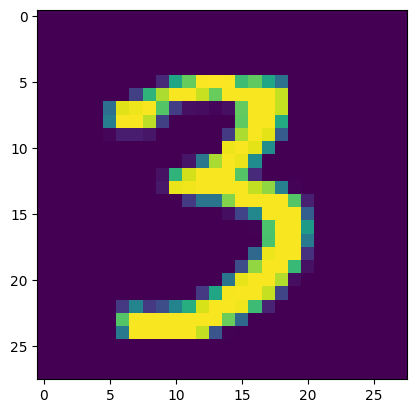

In [17]:
plt.imshow(x_train[10000])

## 3.Data Preparation

### Lets normalize this for faster processing

In [20]:
x_train.min(),x_train.max()

(np.uint8(0), np.uint8(255))

In [21]:
x_test.min(),x_test.max()

(np.uint8(0), np.uint8(255))

In [22]:
x_train=x_train/255.0
x_test=x_test/255.0

In [23]:
x_train.min(),x_train.max()

(np.float64(0.0), np.float64(1.0))

In [24]:
x_test.min(),x_test.max()

(np.float64(0.0), np.float64(1.0))

## 4.Model Building

In [28]:
from keras.models import Sequential
from keras.layers import Flatten,Dense

In [33]:
model = Sequential()
model.add(layer=Flatten())
model.add(Dense(units=100,activation="relu"))
model.add(Dense(units=30,activation="relu"))
model.add(Dense(units=10,activation="softmax"))
#print(model.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [36]:
model.compile(optimizer="rmsprop",loss="sparse_categorical_crossentropy")

## 6.Model Training | 7.Model Testing | 8.Model Evaluation

In [37]:
model.fit(x=x_train,y=y_train,batch_size=32,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.2686 - val_loss: 0.1364
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1202 - val_loss: 0.1048
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0883 - val_loss: 0.1083
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0720 - val_loss: 0.0942
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0606 - val_loss: 0.1013
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0519 - val_loss: 0.0994
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0455 - val_loss: 0.0908
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0397 - val_loss: 0.1084
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0347 - val_loss: 0.1053
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0314 - val_loss: 0.1059


In [38]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (32, 784)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (32, 100)                   │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (32, 30)                    │           3,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (32, 10)                    │             310 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 163,682 (639.39 KB)

 Trainable params: 81,840 (319.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,842 (319.70 KB)

## 9.Model Prediction

In [40]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [43]:
import numpy as np
y_test[400]

np.uint8(2)

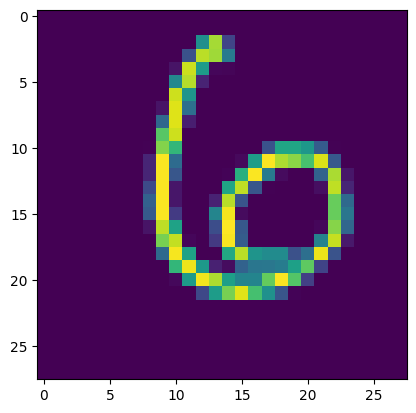

In [45]:
plt.imshow(x_test[100])

In [46]:
import numpy as np
np.argmax(y_pred[100])

np.int64(6)

## ==================THE END=====================================